# Analysis and Prediction of Used Car Prices
* The goal of the project is to deal with a regression task, including complete data cleaning, feature extraction and hyperparameter tuning of several regression models.


## Data Source

We will be dealing with the price prediction of sold automobiles. We have training data available in the `data.csv` file and data for evaluation in the `evaluation.csv` file.

#### Features Description:

* ID - car identifier
* Make - vehicle manufacturer
* Model - vehicle model name
* Price - selling price; **target variable, we are predicting**
* Year - year of manufacture
* Kilometer - number of kilometers driven
* Fuel Type - type of fuel
* Transmission - type of transmission
* Location - city where the sale took place
* Color - vehicle color
* Owner - number of previous owners
* Seller Type - type of selling entity (individual, company)
* Engine - engine volume in cubic centimeters
* Max Power - maximum engine power
* Max Torque - maximum engine torque
* Drivetrain - type of driven axles (FWD - front-wheel drive, RWD - rear-wheel drive, AWD - all-wheel drive)
* Length - vehicle length in mm
* Width - vehicle width in mm
* Height - vehicle height in mm
* Seating Capacity - maximum number of seats
* Fuel Tank Capacity - tank capacity in liters


## Working Procedure
  * We will load data from the `data.csv` file and split it into subsets for training (training set), model comparison (validation set), and the performance prediction of the final model (test set).
  * We will perform basic **data preprocessing** :
    * We will go through the individual features and transform them into a suitable form for use.
    * We will handle missing values.
  * We will apply three regression models to the prepared data: **Decision Tree**, **K-Nearest Neighbours** a **linear regression**:
    * We will experiment with normalization if we expect it to have a positive impact on the given model.
    * We will tune the main hyperparameters and find their best values (to MSE).
    * For the model with the best hyperparameter values on the validation set, we will determine its error using MSE.
  * From all the options tested in the previous step, we will select the **final model** and estimate what error (measured by **RMSE**) we can expect on new data.
    
  * Finally, we will use the model to predict prices for the cars from `evaluation.csv` file.
  * The goal is to minimize RMSE on unknown data.


# Implementation

## Data Preprocessing

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import ParameterGrid
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler, MaxAbsScaler

In [3]:
df = pd.read_csv("data.csv")
display(df.info())
display(df.describe())
display(df.head())
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1683 entries, 0 to 1682
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  1683 non-null   int64  
 1   Make                1683 non-null   object 
 2   Model               1683 non-null   object 
 3   Price               1683 non-null   int64  
 4   Year                1683 non-null   int64  
 5   Kilometer           1683 non-null   int64  
 6   Fuel Type           1683 non-null   object 
 7   Transmission        1683 non-null   object 
 8   Location            1683 non-null   object 
 9   Color               1683 non-null   object 
 10  Owner               1683 non-null   object 
 11  Seller Type         1683 non-null   object 
 12  Engine              1667 non-null   object 
 13  Max Power           1667 non-null   object 
 14  Max Torque          1667 non-null   object 
 15  Drivetrain          1618 non-null   object 
 16  Length

None

,ID,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,1683.000000,1.683000e+03,1683.000000,1.683000e+03,1683.000000,1683.000000,1683.000000,1683.000000,1641.000000
mean,1005.180630,1.570817e+06,2016.569816,5.402617e+04,4276.891266,1767.269162,1592.308378,5.307190,51.919805
std,576.607661,1.790412e+06,3.255157,6.084482e+04,438.106943,134.130438,135.277833,0.814619,15.028163
min,0.000000,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1281.000000,2.000000,15.000000
25%,502.500000,4.950000e+05,2014.000000,2.800000e+04,3985.000000,1695.000000,1485.000000,5.000000,42.000000
50%,1010.000000,8.250000e+05,2017.000000,4.985700e+04,4360.000000,1775.000000,1545.000000,5.000000,48.000000
75%,1502.000000,1.870000e+06,2019.000000,7.200000e+04,4620.000000,1831.000000,1678.000000,5.000000,60.000000
max,1994.000000,1.290000e+07,2022.000000,2.000000e+06,5453.000000,2220.000000,1995.000000,8.000000,104.000000


,ID,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,...,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,1036,BMW,X1 sDrive20d,3250000,2020,32005,Diesel,Automatic,Bangalore,Blue,...,Individual,1995 cc,184 bhp @ 4000 rpm,380 Nm @ 1750 rpm,RWD,4454.0,1798.0,1545.0,5.0,61.0
1,754,Land Rover,Evoque SE Dynamic,6500000,2021,12000,Diesel,Automatic,Hyderabad,White,...,Individual,1999 cc,177 bhp @ 4000 rpm,430 Nm @ 1750 rpm,AWD,4360.0,2120.0,1635.0,5.0,57.0
2,840,Maruti Suzuki,S-Cross Zeta 1.6,800000,2017,52836,Diesel,Manual,Ahmedabad,Blue,...,Individual,1598 cc,118 bhp @ 3750 rpm,320 Nm @ 1750 rpm,FWD,4300.0,1765.0,1590.0,5.0,48.0
3,1127,Land Rover,Evoque HSE,3800000,2017,50000,Diesel,Automatic,Mumbai,White,...,Individual,1999 cc,177 bhp @ 4000 rpm,430 Nm @ 1750 rpm,AWD,4360.0,2120.0,1635.0,5.0,57.0
4,271,BMW,3-Series 320d Luxury Line,2950000,2018,75000,Diesel,Automatic,Coimbatore,White,...,Individual,1995 cc,188 bhp @ 4000 rpm,400 Nm @ 1750 rpm,RWD,4633.0,1811.0,1429.0,5.0,57.0


(1683, 21)

The dataset consists of 21 features and 1683 data points. We've identified missing values in several column, specifically *Engine*, *Max Power*, *Max Torque* a *Drivetrain*. To handle these, we will use **median imputation** for numerical data and **mode imputation** for categorical data.
The following features are already in the correct numerical format:
- *Price*, *Year*, *Kilometer*, *Length*, *Width*, *Height*, *Seating Capacity* and *Fuel Tank Capacity*

All other variables are currently stored as _object_ types, which will require further processing. Let's take a look at the number of unique values for each feature.

In [4]:
def printUniqueObjectValues(df):
    for col in df.columns:
        if df[col].dtype == "object":
            print(f"Feature: {col} has {df[col].nunique()} unique values")
            print("\t", df[col].unique()[:8])
            print("\n")

printUniqueObjectValues(df)

Feature: Make has 30 unique values
	 ['BMW' 'Land Rover' 'Maruti Suzuki' 'Honda' 'Mercedes-Benz' 'Hyundai'
 'Tata' 'MG']


Feature: Model has 919 unique values
	 ['X1 sDrive20d' 'Evoque SE Dynamic' 'S-Cross Zeta 1.6' 'Evoque HSE'
 '3-Series 320d Luxury Line' 'Ciaz VDi SHVS' 'Ertiga VDi' 'City 1.5 V AT']


Feature: Fuel Type has 8 unique values
	 ['Diesel' 'Petrol' 'Petrol + CNG' 'CNG' 'Electric' 'CNG + CNG' 'Hybrid'
 'LPG']


Feature: Transmission has 2 unique values
	 ['Automatic' 'Manual']


Feature: Location has 76 unique values
	 ['Bangalore' 'Hyderabad' 'Ahmedabad' 'Mumbai' 'Coimbatore' 'Lucknow'
 'Agra' 'Gurgaon']


Feature: Color has 16 unique values
	 ['Blue' 'White' 'Silver' 'Grey' 'Red' 'Black' 'Maroon' 'Brown']


Feature: Owner has 6 unique values
	 ['Second' 'First' 'Third' 'UnRegistered Car' 'Fourth' '4 or More']


Feature: Seller Type has 3 unique values
	 ['Individual' 'Corporate' 'Commercial Registration']


Feature: Engine has 101 unique values
	 ['1995 cc' '1999 cc' '

Nominal Categorical Features:
- *Make*, *Transmission*, *Location*, *Color*, *Seller type*, *Drivetrain*, *Model*\
- Note on *Model*: We need to be careful there. Out of roughly 1600 entries, there are 900 unique model names. This high cardinality means the feature offers very little predictive value, so we will drop it from our analysis.
- Note on *Fuel Type*: This column contains a *CNG + CNG* category. It's unclear how this differs from standard *CNG*, so for simplicity we will merge these categories.
- These nominal features will later be transformed using **One-Hot Encoding**.

Ordinal Categorical Features:
- *Owner*: This represents the number of previous owners.

Continuous features:
- *Engine*: We need to clean this field to extract the raw numerical values.
- *Max Power* and *Max Torque*: These features currently contain pairs of values - the actual measurement and the corresponding RPM. To keep the model simple and to avoid redundant features, we'll discard the RPM data as I believe it's unnecessary. However, the power and torque values themselves might be crucial for the prediction.

In [5]:
df["Fuel Type"] = df["Fuel Type"].str.replace("CNG + CNG", "CNG")

# Converting categorical features to the 'category' data type
for col in ["Make", "Transmission", "Location", "Color", "Seller Type", "Drivetrain", "Fuel Type"]:
    df[col] = df[col].astype("category")

# Dropping 'Model' and 'ID' features
df.drop("Model", axis=1, inplace=True)
df.drop("ID", axis=1, inplace=True)

# Converting 'Owner' to an ordinal categorical feature
owner_cat_types = ["UnRegistered Car", "First", "Second", "Third", "Fourth", "4 or More"]
df["Owner"] = df["Owner"].astype(CategoricalDtype(categories=owner_cat_types, ordered=True))

In [6]:
df["Engine"] = df["Engine"].str.replace("cc", "")
df["Engine"] = df["Engine"].astype("float64")

In [7]:
def extractNumber(p):
    if pd.isnull(p):
        return None
    res = re.search(r"[0-9]+(\.[0-9]+)?", str(p))
    return float(res.group())

# Extracting Power and Torque
df["Max Power"] = df["Max Power"].apply(extractNumber)
df["Max Power"] = df["Max Power"].astype("float64")

df["Max Torque"] = df["Max Torque"].apply(extractNumber)
df["Max Torque"] = df["Max Torque"].astype("float64")

All features have now been preprocessed. The next step is to handle missing values. Crucially, this must be done **after** splitting the data into training, validation, and test sets to prevent data leakage—we want to ensure that medians or modes are not influenced by the test data. We will use a standard **60/20/20 split**.

## Building a DataWrapper Class for DataFrames

To simplify repeated DataFrame manipulations and ensure code safety, we’ve created a _DataWrapper_ class. This class stores a local copy of the dataframe, allowing all operations to be performed in isolation within the instance. The class implements the following methods:
- split_data()
- fill_missing()
- one_hot_encode()
- preprocess()
- scale()

From an external perspective, we will always access the __ohe_ (One-Hot Encoded) instances within the _DataWrapper_. This design ensures that every time we call _one_hot_encode()_, we are working with data that is fresh and unaffected by previous modifications, such as scaling or model-specific operations.

In [8]:
random_seed = 42

class DataWrapper:

    def __init__(self, df):
        self.df = df.copy()

        self.x_train = None
        self.x_val = None
        self.x_test = None

        self.y_train = None
        self.y_val = None
        self.y_test = None

        self.x_train_ohe = None
        self.x_val_ohe = None
        self.x_test_ohe = None

        self.encoder = None

        self.preprocess()

    def split_data(self):
        Y = self.df["Price"]
        X = self.df.drop("Price", axis=1)
        self.x_train, self.x_val, self.y_train, self.y_val = train_test_split(X, Y, train_size=0.6, random_state=random_seed)
        self.x_val, self.x_test, self.y_val, self.y_test = train_test_split(self.x_val, self.y_val, train_size=0.5, random_state=random_seed)

    # We always impute missing values using either the median or the mode.
    def fill_missing(self):
        for col in self.df.drop("Price", axis=1).columns:
            if self.x_train[col].dtype == "category":
                missing_value = self.x_train[col].mode()[0]
            elif self.x_train[col].dtype == "int64" or self.x_train[col].dtype == "float64" or self.x_train[col].dtype == "int8":
                missing_value = self.x_train[col].median()
            for data in [self.x_train, self.x_val, self.x_test]:
                data[col] = data[col].fillna(missing_value)

    def one_hot_encode(self):
        category_cols = self.x_train.select_dtypes(include=["category"]).columns.tolist()
        numeric_cols = self.x_train.select_dtypes(include=["int64", "float64", "int8"]).columns.tolist()

        self.encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

        train_cat = self.encoder.fit_transform(self.x_train[category_cols])
        val_cat = self.encoder.transform(self.x_val[category_cols])
        test_cat = self.encoder.transform(self.x_test[category_cols])

        dummy_category_cols = self.encoder.get_feature_names_out(category_cols)

        train_cat_df = pd.DataFrame(train_cat, columns=dummy_category_cols, index=self.x_train.index)
        val_cat_df = pd.DataFrame(val_cat, columns=dummy_category_cols, index=self.x_val.index)
        test_cat_df = pd.DataFrame(test_cat, columns=dummy_category_cols, index=self.x_test.index)

        self.x_train_ohe = pd.concat([train_cat_df, self.x_train[numeric_cols]], axis=1)
        self.x_val_ohe = pd.concat([val_cat_df, self.x_val[numeric_cols]], axis=1)
        self.x_test_ohe = pd.concat([test_cat_df, self.x_test[numeric_cols]], axis=1)

    def scale(self, scaler):
        # Resetting _ohe dataframes to clear any previous modifications for each run.
        self.one_hot_encode()
        if scaler is None:
            return
        numeric_cols = self.x_train.select_dtypes(include=["int64", "float64", "int8"]).columns.tolist()
        scaler.fit(self.x_train_ohe[numeric_cols])
        self.x_train_ohe[numeric_cols] = scaler.transform(self.x_train_ohe[numeric_cols])
        self.x_val_ohe[numeric_cols] = scaler.transform(self.x_val_ohe[numeric_cols])
        self.x_test_ohe[numeric_cols] = scaler.transform(self.x_test_ohe[numeric_cols])

    def preprocess(self):
        self.split_data()
        self.fill_missing()



In [9]:
dw = DataWrapper(df)
dw.one_hot_encode()

## Linear Regression
Linear regression is a robust choice for this task. It is generally less prone to overfitting compared to the other two methods we are testing, though it can be sensitive to datasets with highly correlated features.

### Baseline Run
We will first execute the linear regression model without any additional adjustments or fine-tuning. This will give us a baseline **RMSE** to serve as a reference point for future improvements.

In [10]:
clf = LinearRegression()
clf.fit(dw.x_train_ohe, dw.y_train)
Yval_predict = clf.predict(dw.x_val_ohe)

rmse = root_mean_squared_error(dw.y_val, Yval_predict)
print(rmse)

926683.2610107878


Linear regression yields an RMSE of over 926,000, which is a poor result. Is there anything we can adjust to improve the model's performance?

Currently, the **owner** feature is stored as a _categoricalDType_. How does the _OneHotEncoder_ handle it? We use the encoder for all features passed to it, including numerical ones. Therefore, we only feed it categorical features, which includes owner. Would it be better to treat this feature as numerical? While it’s hard to say if price scales linearly with the number of owners, converting it to numeric would certainly reduce the overall feature count. Note that scaling data for linear regression is unnecessary, as the results would remain the same.

### Scaler Selection and Comparing Owner as Category vs. Numeric

In [11]:
dw_owner_numeric = DataWrapper(df)
dw_owner_numeric.df["Owner"] = dw_owner_numeric.df["Owner"].cat.codes
dw_owner_numeric.preprocess()
dw_owner_numeric.one_hot_encode()

clf.fit(dw.x_train_ohe, dw.y_train)
yval_predict = clf.predict(dw.x_val_ohe)
rmse = root_mean_squared_error(dw.y_val, yval_predict)
print(f"RMSE with owner as category: {rmse}")

clf.fit(dw_owner_numeric.x_train_ohe, dw_owner_numeric.y_train)
yval_predict = clf.predict(dw_owner_numeric.x_val_ohe)
rmse = root_mean_squared_error(dw_owner_numeric.y_val, yval_predict)
print(f"RMSE with owner as int: {rmse}",end="\n\n")

RMSE with owner as category: 926683.2610107878
RMSE with owner as int: 928204.3347212109



The difference in how we approached the _Owner_ feature played a very minor role; the impact on the results was negligible.

## Regression Decision Tree
A major disadvantage of decision trees is their instability—even a small variance in the data can result in a completely different tree structure.

### Baseline Run

In [12]:
clf = DecisionTreeRegressor(random_state=random_seed)
clf.fit(dw.x_train_ohe, dw.y_train)
yval_predict = clf.predict(dw.x_val_ohe)
rmse = root_mean_squared_error(dw.y_val, yval_predict)
print("RMSE:", rmse)

RMSE: 649868.6921332213


### Tuning the Tree's Maximum Depth
Our initial run shows an RMSE of 650k without any adjustments. Let's try the different approaches for the owner feature again, while also tuning the **maximum depth** hyperparameter:

Best depth for categorical: 9
Best RMSE for categorical: 641402.0496848677

Best depth for numerical: 20
Best RMSE for numerical: 633929.5859891616


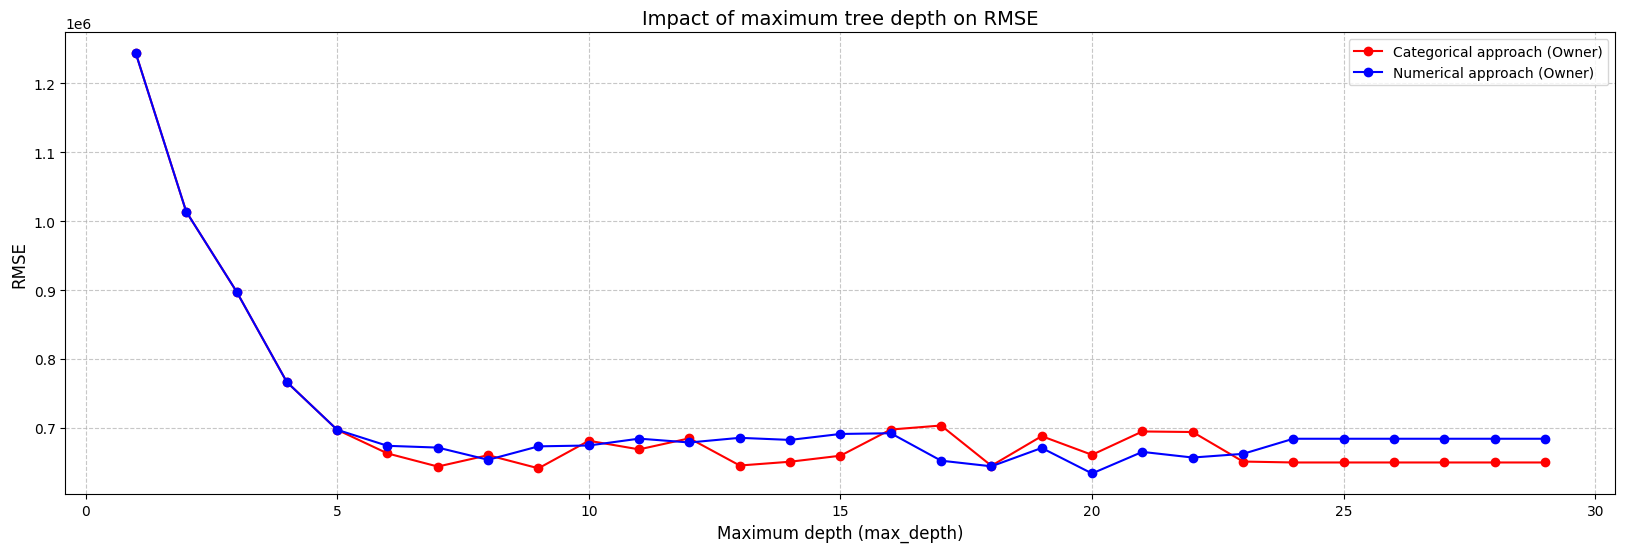

In [13]:
depths = range(1, 30)

rmse_category = []
rmse_numerical = []
for depth in depths:
    clf = DecisionTreeRegressor(random_state=random_seed, max_depth=depth)

    clf.fit(dw.x_train_ohe, dw.y_train)
    yval_predict = clf.predict(dw.x_val_ohe)
    rmse = root_mean_squared_error(dw.y_val, yval_predict)
    rmse_category.append(rmse)

    clf.fit(dw_owner_numeric.x_train_ohe, dw_owner_numeric.y_train)
    yval_predict = clf.predict(dw_owner_numeric.x_val_ohe)
    rmse = root_mean_squared_error(dw_owner_numeric.y_val, yval_predict)
    rmse_numerical.append(rmse)

fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(depths, rmse_category, 'or-', label='Categorical approach (Owner)')
ax.plot(depths, rmse_numerical, 'ob-', label='Numerical approach (Owner)')

ax.set_title("Impact of maximum tree depth on RMSE", fontsize=14)
ax.set_xlabel("Maximum depth (max_depth)", fontsize=12)
ax.set_ylabel("RMSE", fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)

print("Best depth for categorical:", depths[np.argmin(rmse_category)])
print("Best RMSE for categorical:", rmse_category[np.argmin(rmse_category)])
print("")
print("Best depth for numerical:", depths[np.argmin(rmse_numerical)])
print("Best RMSE for numerical:", rmse_numerical[np.argmin(rmse_numerical)])

We achieved the best results with a depth of 20. However, the tree has other hyperparameters to consider. Besides depth, we can experiment with different splitting criteria, the minimum number of data points per leaf, or the minimum number of samples required for a split.

### Tuning Other Hyperparameters

In [14]:
param_grid = {
    "max_depth": range(1, 25),
    "min_samples_leaf": range(1, 20),
    "criterion": ["squared_error", "friedman_mse", "poisson"]
}
param_comb = ParameterGrid(param_grid)

val_rmse = []

dw.one_hot_encode()
for params in param_comb:
    clf = DecisionTreeRegressor(**params, random_state=random_seed)
    clf.fit(dw.x_train_ohe, dw.y_train)
    val_rmse.append(root_mean_squared_error(dw.y_val,clf.predict(dw.x_val_ohe)))
best_params = param_comb[np.argmin(val_rmse)]
clf = DecisionTreeRegressor(**best_params, random_state=random_seed)
clf.fit(dw.x_train_ohe, dw.y_train)
valid_rmse_tree = root_mean_squared_error(dw.y_val, clf.predict(dw.x_val_ohe))
print(f"RMSE (valid) with categorical owner and params: {best_params}: \t{valid_rmse_tree:.0f}")

val_rmse = []

dw_owner_numeric.one_hot_encode()
for params in param_comb:
    clf = DecisionTreeRegressor(**params, random_state=random_seed)
    clf.fit(dw_owner_numeric.x_train_ohe, dw_owner_numeric.y_train)
    val_rmse.append(root_mean_squared_error(dw_owner_numeric.y_val,clf.predict(dw_owner_numeric.x_val_ohe)))
best_params = param_comb[np.argmin(val_rmse)]
clf = (DecisionTreeRegressor(**best_params, random_state=random_seed))
clf.fit(dw_owner_numeric.x_train_ohe, dw_owner_numeric.y_train)
valid_rmse_tree = root_mean_squared_error(dw_owner_numeric.y_val, clf.predict(dw_owner_numeric.x_val_ohe))
print(f"RMSE (valid) with numerical owner and params: {best_params}: \t{valid_rmse_tree:.0f}")

RMSE (valid) with categorical owner and params: {'min_samples_leaf': 2, 'max_depth': 8, 'criterion': 'poisson'}: 	555508
RMSE (valid) with numerical owner and params: {'min_samples_leaf': 2, 'max_depth': 8, 'criterion': 'poisson'}: 	553585


Excellent – we've reduced the **RMSE to 553k**. In this case, treating owner as a numerical feature performs slightly better.

## K-Nearest Neighbors (KNN)
This method effectively handles outliers. For instance, if the dataset includes a Ferrari that skews the average price, KNN remains unaffected because it only considers the most similar data points for evaluation. However, it struggles with **high dimensionality**, as the density of data points in the feature space decreases as the number of dimensions increases.

### Baseline Run

In [15]:
from sklearn.neighbors import KNeighborsRegressor

clf = KNeighborsRegressor()
dw.one_hot_encode()
clf.fit(dw.x_train_ohe, dw.y_train)

yval_predict = clf.predict(dw.x_val_ohe)
rmse = root_mean_squared_error(dw.y_val, yval_predict)
print("RMSE:", rmse)

RMSE: 1242412.655020118


Without any adjustments, KNN currently shows the worst RMSE. Unlike the previous two models, KNN is extremely sensitive to **data scaling**. Our dataset contains widely varying ranges—binary values from one-hot encoding versus mileage in the hundreds of thousands.

Which scaler will perform best? We will run KNN using a _ParameterGrid_ to test various metrics, neighbor counts, and weighting schemes. Note that this cell takes a significant amount of time to execute due to the high number of combinations.

### Hyperparameter Tuning

In [16]:
from sklearn.model_selection import ParameterGrid

param_grid = {
    'n_neighbors': range(2,15),
    'metric': ['minkowski'],
    'p': [1, 2, 3, 4, 5],
    'weights': ['uniform', 'distance'],
}
param_comb = ParameterGrid(param_grid)

scalers = { "No Scaler" : None, "StandardScaler" : StandardScaler(),
            "MinMaxScaler" : MinMaxScaler(), "RobustScaler" : RobustScaler(),
            "MaxAbsScaler" : MaxAbsScaler()}
for dw_name, dw_iter in {"categorical owner": dw, "numerical owner": dw_owner_numeric}.items():
    for name, scaler in scalers.items():
        dw_iter.scale(scaler)
        val_rmse = []
        for params in param_comb:
            clf = KNeighborsRegressor(**params)
            clf.fit(dw_iter.x_train_ohe, dw_iter.y_train)
            val_rmse.append(root_mean_squared_error(dw_iter.y_val,clf.predict(dw_iter.x_val_ohe)))
        best_params = param_comb[np.argmin(val_rmse)]

        clf = KNeighborsRegressor(**best_params).fit(dw_iter.x_train_ohe, dw_iter.y_train)
        valid_rmse_tree = root_mean_squared_error(dw_iter.y_val, clf.predict(dw_iter.x_val_ohe))
        print(f"RMSE (valid) with {dw_name} and {scaler} and params: {best_params}: \t{valid_rmse_tree:.0f}")


RMSE (valid) with categorical owner and None and params: {'weights': 'distance', 'p': 1, 'n_neighbors': 5, 'metric': 'minkowski'}: 	1085427
RMSE (valid) with categorical owner and StandardScaler() and params: {'weights': 'distance', 'p': 2, 'n_neighbors': 6, 'metric': 'minkowski'}: 	624669
RMSE (valid) with categorical owner and MinMaxScaler() and params: {'weights': 'distance', 'p': 5, 'n_neighbors': 2, 'metric': 'minkowski'}: 	875282
RMSE (valid) with categorical owner and RobustScaler() and params: {'weights': 'distance', 'p': 1, 'n_neighbors': 2, 'metric': 'minkowski'}: 	671084
RMSE (valid) with categorical owner and MaxAbsScaler() and params: {'weights': 'distance', 'p': 1, 'n_neighbors': 2, 'metric': 'minkowski'}: 	921537
RMSE (valid) with numerical owner and None and params: {'weights': 'distance', 'p': 1, 'n_neighbors': 5, 'metric': 'minkowski'}: 	1085447
RMSE (valid) with numerical owner and StandardScaler() and params: {'weights': 'distance', 'p': 1, 'n_neighbors': 5, 'metric

The best results were achieved using _StandardScaler_, so we will stick with it for the remainder of our experiments. Now, we'll try removing certain columns, given KNN's sensitivity to dimensionality. We'll start with the **Location** feature, as it has the highest number of unique values.

### Dropping the _Location_ Feature

In [17]:
def find_best_params_knn(dw_knn: DataWrapper, dw_knn_owner_numeric: DataWrapper):
    scaler = StandardScaler()
    for dw_name, dw_iter in {"dw knn categorical owner" : dw_knn,"dw knn numerical owner" : dw_knn_owner_numeric}.items():
        dw_iter.scale(scaler)
        val_rmse = []
        for params in param_comb:
            clf = KNeighborsRegressor(**params)
            clf.fit(dw_iter.x_train_ohe, dw_iter.y_train)
            val_rmse.append(root_mean_squared_error(dw_iter.y_val,clf.predict(dw_iter.x_val_ohe)))
        best_params = param_comb[np.argmin(val_rmse)]

        clf = KNeighborsRegressor(**best_params).fit(dw_iter.x_train_ohe, dw_iter.y_train)
        valid_rmse_tree = root_mean_squared_error(dw_iter.y_val, clf.predict(dw_iter.x_val_ohe))
        print(f"RMSE (valid) with {dw_name} and {scaler} and params: {best_params}: \t{valid_rmse_tree:.0f}")


In [18]:
dw_dropped = DataWrapper(dw.df.drop("Location", axis = 1, inplace=False))
dw_numeric_dropped = DataWrapper(dw_owner_numeric.df.drop("Location", axis = 1, inplace=False))

find_best_params_knn(dw_dropped, dw_numeric_dropped)

RMSE (valid) with dw knn categorical owner and StandardScaler() and params: {'weights': 'distance', 'p': 2, 'n_neighbors': 4, 'metric': 'minkowski'}: 	599351
RMSE (valid) with dw knn numerical owner and StandardScaler() and params: {'weights': 'distance', 'p': 1, 'n_neighbors': 3, 'metric': 'minkowski'}: 	605457


Removing the Location feature helped reduce the RMSE by approximately 30k. Let’s try dropping other features as well. We'll test **Make** (30 unique values, though I expect it to be important) and **Color** (16 unique values, likely less significant).

### Dropping the *Make* Feature

In [19]:
dw_dropped = DataWrapper(dw.df.drop("Make", axis = 1, inplace=False))
dw_numeric_dropped = DataWrapper(dw_owner_numeric.df.drop("Make", axis = 1, inplace=False))

find_best_params_knn(dw_dropped, dw_numeric_dropped)

RMSE (valid) with dw knn categorical owner and StandardScaler() and params: {'weights': 'distance', 'p': 2, 'n_neighbors': 7, 'metric': 'minkowski'}: 	652876
RMSE (valid) with dw knn numerical owner and StandardScaler() and params: {'weights': 'distance', 'p': 1, 'n_neighbors': 5, 'metric': 'minkowski'}: 	674240


As expected, *Make* was important...

### Dropping the *Color* Feature

In [20]:
dw_dropped = DataWrapper(dw.df.drop("Color", axis = 1, inplace=False))
dw_numeric_dropped = DataWrapper(dw_owner_numeric.df.drop("Color", axis = 1, inplace=False))

find_best_params_knn(dw_dropped, dw_numeric_dropped)

RMSE (valid) with dw knn categorical owner and StandardScaler() and params: {'weights': 'distance', 'p': 3, 'n_neighbors': 5, 'metric': 'minkowski'}: 	641972
RMSE (valid) with dw knn numerical owner and StandardScaler() and params: {'weights': 'distance', 'p': 1, 'n_neighbors': 5, 'metric': 'minkowski'}: 	652305


Surprisingly, even this didn't yield an improvement, so we will keep the Color feature.

## Merging Training and Validation Data for Final Model Training.

We have selected KNN as our final model. Although its RMSE is slightly higher than the decision tree's, it is a more robust choice. We will configure the final KNN model as follows:
 - **Feature handling:** _Owner_ as categorical, _Location_ removed.
 - **Preprocessing**: _StandardScaler_
 - **Hyperparameters**: {'weights': 'distance', 'p': 2, 'n_neighbors': 4, 'metric': 'minkowski'}


### Final Model Construction

We will now use the combined training and validation datasets to train our final model.

In [21]:
clf = KNeighborsRegressor(n_neighbors=4, metric="minkowski", p=2, weights="distance")
scaler = StandardScaler()
dw_final = DataWrapper(dw.df.drop("Color", axis = 1, inplace=False))
dw_final.one_hot_encode()

x_train_val_ohe = pd.concat([dw_final.x_train_ohe, dw_final.x_val_ohe], axis=0)
y_train_val = pd.concat([dw_final.y_train, dw_final.y_val], axis=0)

numeric_cols = dw_final.x_train.select_dtypes(include=["int64", "float64", "int8"]).columns.tolist()

scaler.fit(x_train_val_ohe[numeric_cols])
x_train_val_ohe[numeric_cols] = scaler.transform(x_train_val_ohe[numeric_cols])
dw_final.x_test_ohe[numeric_cols] = scaler.transform(dw_final.x_test_ohe[numeric_cols])

clf.fit(x_train_val_ohe, y_train_val);

### Predicting the RMSE Score on the Test Set

In [22]:
y_test_predict = clf.predict(dw_final.x_test_ohe)
rmse = root_mean_squared_error(dw_final.y_test, y_test_predict)
print("RMSE:", rmse)


RMSE: 702925.1634096964


The RMSE of the chosen model is within an acceptable range and aligns with our expectations.

## Price Prediction on evaluation.csv

### Preprocessing the Evaluation DataFrame
We will now process the evaluation DataFrame to ensure its structure and features match the training data schema.

In [23]:
df_eval = pd.read_csv("evaluation.csv")
eval_id = df_eval["ID"]

df_eval["Fuel Type"] = df_eval["Fuel Type"].str.replace("CNG + CNG", "CNG")

# Converting categorical features to the 'category' data type
for col in ["Make", "Transmission", "Location", "Color", "Seller Type", "Drivetrain", "Fuel Type"]:
    df_eval[col] = df_eval[col].astype("category")

# Dropping 'Model', 'ID' and 'Color' features
df_eval.drop("Model", axis=1, inplace=True)
df_eval.drop("ID", axis=1, inplace=True)
df_eval.drop("Color", axis=1, inplace=True)


# Converting the 'Owner' feature to an ordinal categorical type
owner_cat_types = ["UnRegistered Car", "First", "Second", "Third", "Fourth", "4 or More"]
df_eval["Owner"] = df_eval["Owner"].astype(CategoricalDtype(categories=owner_cat_types, ordered=True))


df_eval["Engine"] = df_eval["Engine"].str.replace("cc", "")
df_eval["Engine"] = df_eval["Engine"].astype("float64")

df_eval["Max Power"] = df_eval["Max Power"].apply(extractNumber)
df_eval["Max Power"] = df_eval["Max Power"].astype("float64")

df_eval["Max Torque"] = df_eval["Max Torque"].apply(extractNumber)
df_eval["Max Torque"] = df_eval["Max Torque"].astype("float64")


for col in df_eval.columns:
    if dw_final.x_train[col].dtype == "category":
        missing_value = dw_final.x_train[col].mode()[0]
    elif dw_final.x_val[col].dtype == "int64" or dw_final.x_val[col].dtype == "float64" or dw_final.x_val[col].dtype == "float64":
        missing_value = dw_final.x_val[col].median()
    df_eval[col] = df_eval[col].fillna(missing_value)

category_cols = df_eval.select_dtypes(include=["category"]).columns.tolist()
numeric_cols = df_eval.select_dtypes(include=["int64", "float64", "int8"]).columns.tolist()

eval_cat = dw_final.encoder.transform(df_eval[category_cols])
dummy_cat_cols = dw_final.encoder.get_feature_names_out(category_cols)

eval_cat_df = pd.DataFrame(eval_cat, columns=dummy_cat_cols, index=df_eval.index)
eval_ohe = pd.concat([eval_cat_df, df_eval[numeric_cols]], axis=1)

eval_ohe[numeric_cols] = scaler.transform(eval_ohe[numeric_cols])


### Prediction

In [24]:
eval_predict = pd.DataFrame(clf.predict(eval_ohe))

result = pd.concat([eval_id, eval_predict], axis=1)
result.columns = ["ID", "Price"]
result.to_csv("results.csv", index=False)

## Conclusion

I have selected the **K-Nearest Neighbors** (KNN) method as the final model for this task. It originally achieved an RMSE score of 599k during the training/validation phase. When applied to the unseen test data, the RMSE increased to **703k**, which represents a satisfactory and realistic performance for this model.